# GoEmotions — Cleaning + EDA (Merged Notebook)

EDA is done after cleaning the code and reuses variable names such as (`general_df`, `general_clean`, `emotion_cols`).

## Step 1 — Import Library and Dataset


In [1]:
# Import essential library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re


In [2]:
# Import dataset 
general_df = pd.read_csv("goemotions_mrm8488_train.csv")

print("Number of rows:", general_df.shape[0])
print("Number of columns:", general_df.shape[1])


Number of rows: 211225
Number of columns: 37


In [3]:
general_df.head()


,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,That game hurt.,eew5j0j,Brdd9,nrl,t3_ajis4z,t1_eew18eq,1.548381e+09,1,False,0,...,0,0,0,0,0,0,0,1,0,0
1,>sexuality shouldn’t be a grouping category I...,eemcysk,TheGreen888,unpopularopinion,t3_ai4q37,t3_ai4q37,1.548084e+09,37,True,0,...,0,0,0,0,0,0,0,0,0,0
2,"You do right, if you don't care then fuck 'em!",ed2mah1,Labalool,confessions,t3_abru74,t1_ed2m7g7,1.546428e+09,37,False,0,...,0,0,0,0,0,0,0,0,0,1
3,Man I love reddit.,eeibobj,MrsRobertshaw,facepalm,t3_ahulml,t3_ahulml,1.547965e+09,18,False,0,...,1,0,0,0,0,0,0,0,0,0
4,"[NAME] was nowhere near them, he was by the Fa...",eda6yn6,American_Fascist713,starwarsspeculation,t3_ackt2f,t1_eda65q2,1.546669e+09,2,False,0,...,0,0,0,0,0,0,0,0,0,1


In [4]:
general_df.tail()


,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
211220,Everyone likes [NAME].,ee6pagw,Senshado,heroesofthestorm,t3_agjf24,t3_agjf24,1.547634e+09,16,False,0,...,1,0,0,0,0,0,0,0,0,0
211221,Well when you’ve imported about a gazillion of...,ef28nod,5inchloser,nottheonion,t3_ak26t3,t3_ak26t3,1.548553e+09,15,False,0,...,0,0,0,0,0,0,0,0,0,0
211222,That looks amazing,ee8hse1,springt1me,shittyfoodporn,t3_agrnqb,t3_agrnqb,1.547684e+09,70,False,1,...,0,0,0,0,0,0,0,0,0,0
211223,The FDA has plenty to criticize. But like here...,edrhoxh,enamedata,medicine,t3_aejqzd,t1_edrgdtx,1.547169e+09,4,False,0,...,0,0,0,0,0,0,0,0,0,0
211224,Desktop link: ^^/r/HelperBot_ ^^Downvote ^^to ...,edze9g4,HelperBot_,MorbidReality,t3_afhw30,t1_edze91s,1.547397e+09,61,True,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
general_df.sample(3, random_state=42)


,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
65844,Literally everywhere. There's nothing especial...,eeochpb,KyleG,texas,t3_aiibrx,t1_eeo49lo,1.548139e+09,37,False,0,...,0,0,0,0,0,0,0,0,0,0
54522,"[NAME] and [NAME] may be stronger, but [NAME] ...",eewnhep,King_Jorza,freefolk,t3_ajihmn,t3_ajihmn,1.548397e+09,16,False,0,...,0,0,0,0,0,0,0,0,0,1
48835,Ik I’m crying rn,ee4utnt,lloydness21,Paladins,t3_agaxxw,t1_ee4tpmc,1.547575e+09,76,False,0,...,0,0,0,0,0,0,0,1,0,0


## Step 2 — Understanding the Dataset Structure


In [6]:
general_df.columns


Index(['text', 'id', 'author', 'subreddit', 'link_id', 'parent_id',
       'created_utc', 'rater_id', 'example_very_unclear', 'admiration',
       'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion',
       'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust',
       'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy',
       'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief',
       'remorse', 'sadness', 'surprise', 'neutral'],
      dtype='str')

In [7]:
emotion_cols = general_df.columns[9:].tolist()

# All emotions
print("Number of emotion labels:", len(emotion_cols))
print(emotion_cols)


Number of emotion labels: 28
['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


In [8]:
print("DataTypes :", general_df.dtypes)

print(general_df.info())


DataTypes : text                        str
id                          str
author                      str
subreddit                   str
link_id                     str
parent_id                   str
created_utc             float64
rater_id                  int64
example_very_unclear       bool
admiration                int64
amusement                 int64
anger                     int64
annoyance                 int64
approval                  int64
caring                    int64
confusion                 int64
curiosity                 int64
desire                    int64
disappointment            int64
disapproval               int64
disgust                   int64
embarrassment             int64
excitement                int64
fear                      int64
gratitude                 int64
grief                     int64
joy                       int64
love                      int64
nervousness               int64
optimism                  int64
pride                     in

In [9]:
general_df.describe(include='all')


,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
count,211225,211225,211225,211225,211225,211225,2.112250e+05,211225.000000,211225,211225.000000,...,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000
unique,57732,58011,49178,483,44897,54924,NaN,NaN,2,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Thank you.,eew5j0j,[deleted],cringe,t3_ae6ejj,t3_ae6ejj,NaN,NaN,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,45,5,3882,895,92,64,NaN,NaN,207814,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,1.547659e+09,37.619742,NaN,0.081103,...,0.038779,0.008569,0.041259,0.006164,0.041591,0.006102,0.011954,0.031994,0.026105,0.261797
std,NaN,NaN,NaN,NaN,NaN,NaN,7.696842e+05,23.070528,NaN,0.272994,...,0.193067,0.092172,0.198890,0.078269,0.199653,0.077880,0.108679,0.175985,0.159448,0.439614
min,NaN,NaN,NaN,NaN,NaN,NaN,1.546301e+09,0.000000,NaN,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,1.546993e+09,19.000000,NaN,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,1.547664e+09,37.000000,NaN,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,1.548320e+09,57.000000,NaN,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000


## Step 3 — Data Quality Analysis (raw dataset, before cleaning)


In [10]:
# missing values if any

missing_values = general_df.isnull().sum()

missing_values[missing_values > 0]


Series([], dtype: int64)

In [11]:
missing_percentage = (general_df.isnull().sum() / len(general_df)) * 100

missing_summary = pd.DataFrame({
    'Missing Values': general_df.isnull().sum(),
    'Missing Percentage': missing_percentage
})

missing_summary


,Missing Values,Missing Percentage
text,0,0.0
id,0,0.0
author,0,0.0
subreddit,0,0.0
link_id,0,0.0
parent_id,0,0.0
created_utc,0,0.0
rater_id,0,0.0
example_very_unclear,0,0.0
admiration,0,0.0


In [12]:
# Duplicate values if any

duplicate_count = general_df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

print("Duplicate IDs:", general_df['id'].duplicated().sum())

print("Duplicate texts:", general_df['text'].duplicated().sum())


Number of duplicate rows: 0
Duplicate IDs: 153214
Duplicate texts: 153493


In [13]:
# Empty strings

empty_text = (general_df['text'].str.strip() == '').sum()

print("Empty text records:", empty_text)


Empty text records: 0


In [14]:
# unclear examples:

print(general_df['example_very_unclear'].value_counts())
print("\n")
print(general_df['example_very_unclear'].value_counts(normalize=True) * 100)


example_very_unclear
False    207814
True       3411
Name: count, dtype: int64


example_very_unclear
False    98.385134
True      1.614866
Name: proportion, dtype: float64


In [15]:
print("Unique texts:", general_df['text'].nunique())

print("Texts appearing more than once:",
      (general_df['text'].value_counts() > 1).sum())


Unique texts: 57732
Texts appearing more than once: 57663


## Step 4 — Raw Emotion Label Exploration (multi-hot, before cleaning)

This section describes the *raw* dataset, where each row is one annotator's vote and one text can have several rows (one per rater) plus several emotion columns marked at once. 

#### 4.1 Emotion frequency/distribution


In [16]:
missing_emotion_cols = [col for col in emotion_cols if col not in general_df.columns]

print("Missing emotion columns:", missing_emotion_cols)


Missing emotion columns: []


In [17]:
general_df[emotion_cols].head()


,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,disappointment,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [18]:
# to check for binary

general_df[emotion_cols].apply(pd.Series.unique)


,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,disappointment,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,0,1,1


In [19]:
# Emotions table in detail

emotion_counts = general_df[emotion_cols].sum().sort_values(ascending=False)

emotion_summary = pd.DataFrame({
    'Emotion': emotion_counts.index,
    'Count': emotion_counts.values
})

emotion_summary['Percentage'] = (
    emotion_summary['Count'] / len(general_df) * 100
).round(2)

emotion_summary


,Emotion,Count,Percentage
0,neutral,55298,26.18
1,approval,17620,8.34
2,admiration,17131,8.11
3,annoyance,13618,6.45
4,gratitude,11625,5.50
5,disapproval,11424,5.41
6,curiosity,9692,4.59
7,amusement,9245,4.38
8,realization,8785,4.16
9,optimism,8715,4.13


In [20]:
print("Most Common Emotion : ", emotion_summary.iloc[0])
print("\n")
print("Least Common Emotion :", emotion_summary.iloc[-1])


Most Common Emotion :  Emotion       neutral
Count           55298
Percentage      26.18
Name: 0, dtype: object


Least Common Emotion : Emotion       grief
Count           673
Percentage     0.32
Name: 27, dtype: object


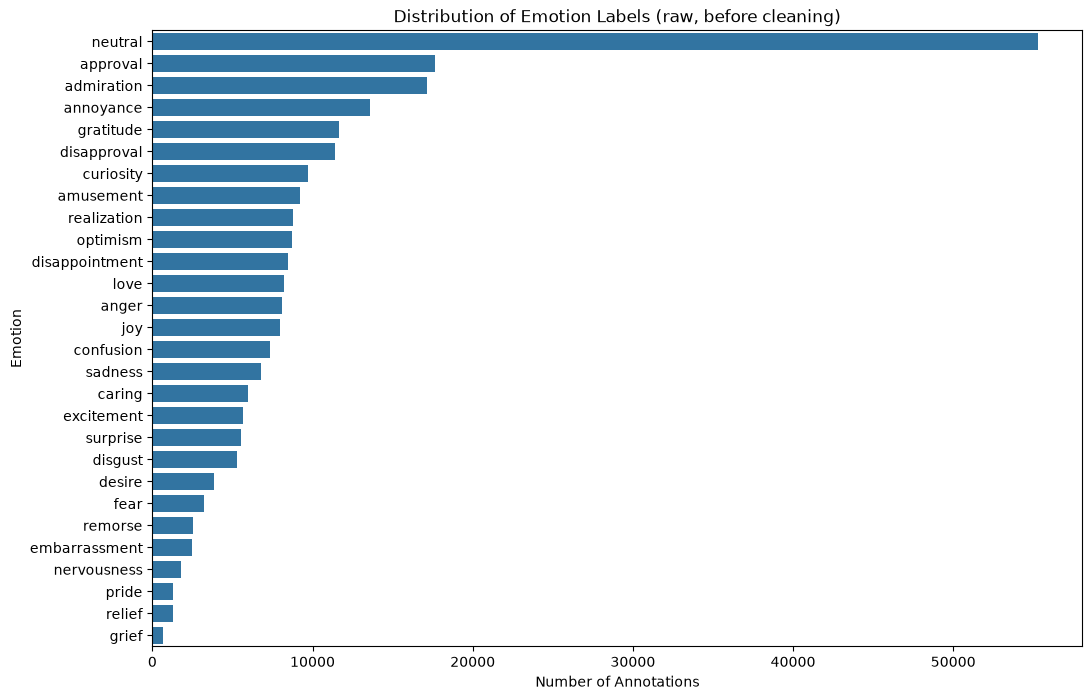

In [21]:
plt.figure(figsize=(12, 8))

sns.barplot(
    data=emotion_summary,
    x='Count',
    y='Emotion'
)

plt.title('Distribution of Emotion Labels (raw, before cleaning)')
plt.xlabel('Number of Annotations')
plt.ylabel('Emotion')

plt.show()


#### 4.2 Multi-Label Distribution


In [22]:
label_counts_per_row = general_df[emotion_cols].sum(axis=1)

label_counts_per_row.value_counts().sort_index()


0       3411
1     171820
2      31187
3       4218
4        399
5        106
6         53
7         20
8          6
9          3
10         1
12         1
Name: count, dtype: int64

In [23]:
label_counts_per_row.describe()


count    211225.000000
mean          1.181342
std           0.498757
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          12.000000
dtype: float64

In [24]:
# for multiple emotions

multiple_label_count = (label_counts_per_row > 1).sum()

multiple_label_percentage = (multiple_label_count / len(general_df)) * 100

print("Annotations with multiple emotion labels:", multiple_label_count)
print("Percentage with multiple emotion labels:", round(multiple_label_percentage, 2), "%")


Annotations with multiple emotion labels: 35994
Percentage with multiple emotion labels: 17.04 %


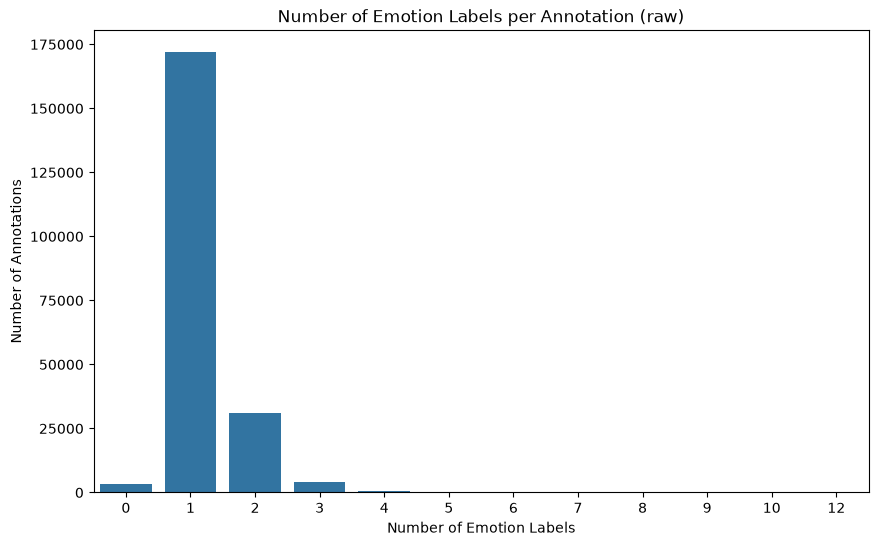

In [25]:
plt.figure(figsize=(10, 6))

sns.countplot(x=label_counts_per_row)

plt.title('Number of Emotion Labels per Annotation (raw)')
plt.xlabel('Number of Emotion Labels')
plt.ylabel('Number of Annotations')

plt.show()


In [26]:
# Rows with no emotion label

no_label_count = (label_counts_per_row == 0).sum()

print("Annotations with no emotion label:", no_label_count)
print("Percentage with no emotion label:", round((no_label_count / len(general_df)) * 100, 2), "%")


Annotations with no emotion label: 3411
Percentage with no emotion label: 1.61 %


In [27]:
# Rows with only one emotion label

single_label_count = (label_counts_per_row == 1).sum()

print("Annotations with exactly one emotion:", single_label_count)
print("Percentage with exactly one emotion:", round((single_label_count / len(general_df)) * 100, 2), "%")


Annotations with exactly one emotion: 171820
Percentage with exactly one emotion: 81.34 %


In [28]:
unclear_and_no_label = (
    general_df['example_very_unclear'] &
    (label_counts_per_row == 0)
).sum()

print("Unclear examples with no emotion label:", unclear_and_no_label)

unclear_with_label = (
    general_df['example_very_unclear'] &
    (label_counts_per_row > 0)
).sum()

print("Unclear examples with at least one emotion label:", unclear_with_label)


Unclear examples with no emotion label: 3411
Unclear examples with at least one emotion label: 0


In [29]:
general_df.loc[
    label_counts_per_row == label_counts_per_row.max(),
    ['text'] + emotion_cols
]

print("Maximum number of labels:", label_counts_per_row.max())


Maximum number of labels: 12


#### 4.3 Class Imbalance Analysis


In [30]:
most_common_count = emotion_counts.max()
least_common_count = emotion_counts.min()

imbalance_ratio = most_common_count / least_common_count

print("Most common emotion count:", most_common_count)
print("Least common emotion count:", least_common_count)
print("Imbalance ratio:", round(imbalance_ratio, 2))


Most common emotion count: 55298
Least common emotion count: 673
Imbalance ratio: 82.17


In [31]:
print("Top 5 most frequent emotions:")
print(emotion_summary.head(5))

print("\nBottom 5 least frequent emotions:")
print(emotion_summary.tail(5))


Top 5 most frequent emotions:
      Emotion  Count  Percentage
0     neutral  55298       26.18
1    approval  17620        8.34
2  admiration  17131        8.11
3   annoyance  13618        6.45
4   gratitude  11625        5.50

Bottom 5 least frequent emotions:
          Emotion  Count  Percentage
23  embarrassment   2476        1.17
24    nervousness   1810        0.86
25          pride   1302        0.62
26         relief   1289        0.61
27          grief    673        0.32


In [32]:
highest_percentage = emotion_summary['Percentage'].max()
lowest_percentage = emotion_summary['Percentage'].min()

print("Highest emotion percentage:", highest_percentage, "%")
print("Lowest emotion percentage:", lowest_percentage, "%")


Highest emotion percentage: 26.18 %
Lowest emotion percentage: 0.32 %


#### 4.4 Emotion Co-occurrence Analysis


In [33]:
co_occurrence = general_df[emotion_cols].T.dot(general_df[emotion_cols])

co_occurrence


,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,disappointment,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
admiration,17131,383,63,158,1366,249,162,322,222,178,...,721,45,603,236,384,50,47,127,226,0
amusement,383,9245,65,155,418,56,138,219,59,91,...,237,15,230,18,239,23,33,90,117,0
anger,63,65,8084,1391,107,50,81,104,33,279,...,86,27,60,4,113,9,34,134,49,0
annoyance,158,155,1391,13618,247,98,171,272,62,754,...,87,50,168,17,255,21,57,186,92,0
approval,1366,418,107,247,17620,442,192,334,192,206,...,325,31,748,71,829,81,73,148,148,0
caring,249,56,50,98,442,5999,37,108,116,59,...,285,21,404,33,176,42,54,166,32,0
confusion,162,138,81,171,192,37,7359,754,32,100,...,59,34,83,8,205,8,46,59,140,0
curiosity,322,219,104,272,334,108,754,9692,175,135,...,115,42,207,29,408,12,61,143,323,0
desire,222,59,33,62,192,116,32,175,3817,85,...,167,14,356,24,92,11,17,65,22,0
disappointment,178,91,279,754,206,59,100,135,85,8469,...,84,114,138,15,296,9,104,907,85,0


In [34]:
from itertools import combinations

pair_counts = []

for emotion1, emotion2 in combinations(emotion_cols, 2):
    count = co_occurrence.loc[emotion1, emotion2]
    pair_counts.append((emotion1, emotion2, count))

pair_counts = pd.DataFrame(
    pair_counts,
    columns=['Emotion 1', 'Emotion 2', 'Co-occurrence']
)

pair_counts = pair_counts.sort_values(
    'Co-occurrence',
    ascending=False
)

pair_counts.head(20)


,Emotion 1,Emotion 2,Co-occurrence
53,anger,annoyance,1391
3,admiration,approval,1366
14,admiration,gratitude,1165
84,annoyance,disapproval,1039
222,disappointment,sadness,907
276,excitement,joy,869
119,approval,realization,829
147,confusion,curiosity,754
83,annoyance,disappointment,754
117,approval,optimism,748


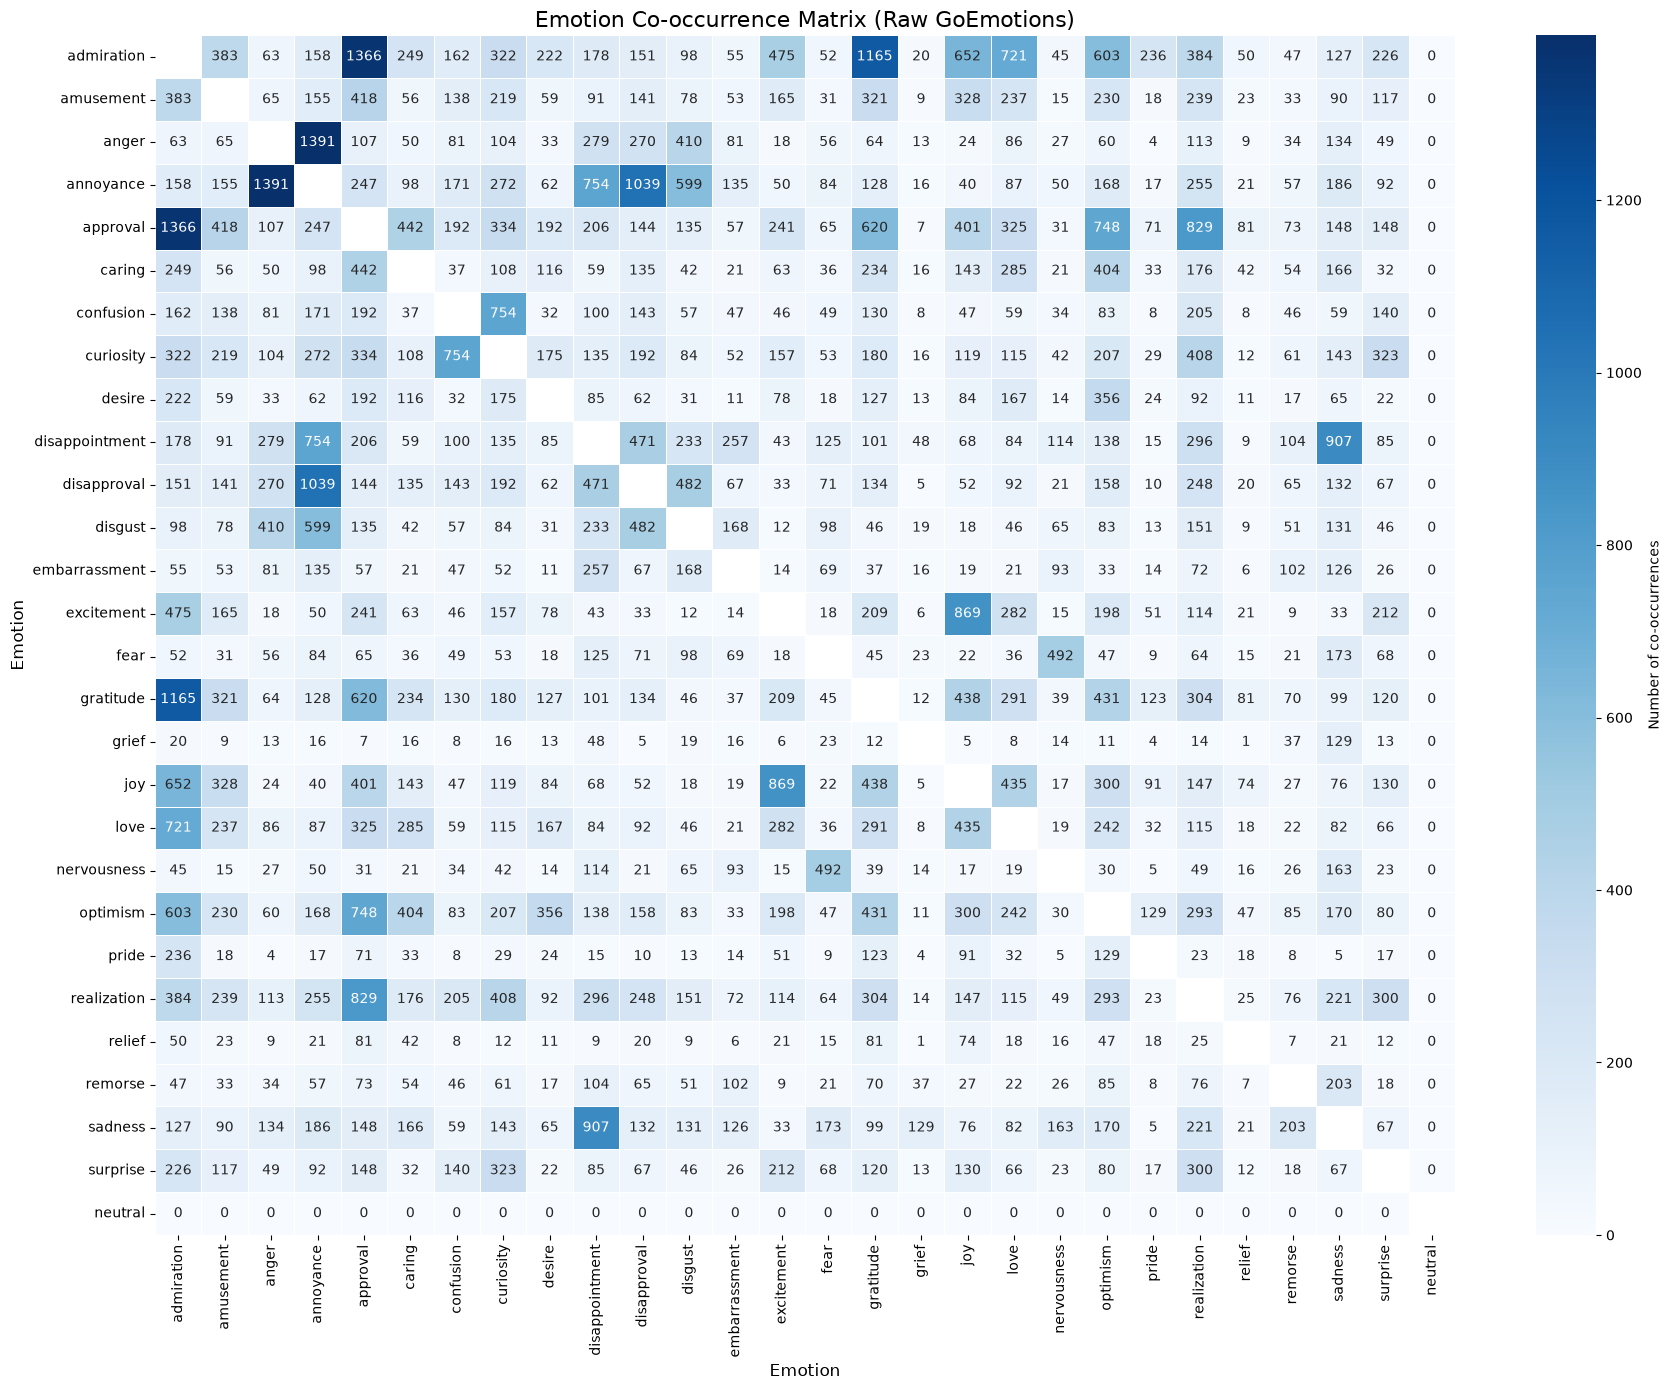

In [ ]:
# Visualising how often different emotions were annotated together in the raw GoEmotions dataset

plt.figure(figsize=(18, 14))

# Mask the diagonal because it represents each emotion with itself
mask = np.eye(co_occurrence.shape[0], dtype=bool)

sns.heatmap(
    co_occurrence,
    mask=mask,
    cmap="Blues",
    annot=True,
    fmt="d",
    linewidths=0.5,
    cbar_kws={"label": "Number of co-occurrences"}
)

plt.title("Emotion Co-occurrence Matrix (Raw GoEmotions)", fontsize=16)
plt.xlabel("Emotion", fontsize=12)
plt.ylabel("Emotion", fontsize=12)

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


In [36]:
# top 10 pairs
pair_counts.head(10)


,Emotion 1,Emotion 2,Co-occurrence
53,anger,annoyance,1391
3,admiration,approval,1366
14,admiration,gratitude,1165
84,annoyance,disapproval,1039
222,disappointment,sadness,907
276,excitement,joy,869
119,approval,realization,829
147,confusion,curiosity,754
83,annoyance,disappointment,754
117,approval,optimism,748


#### 4.5 — Conclusion for the raw-data phase


In the raw dataset, there are 28 emotions with varying degrees of representation among them. The emotion label `neutral` occurs most frequently (55,298 times, or 26.18%), while the least frequent label is `grief` with 673 occurrences (0.32%). There is an imbalance in the distribution of emotion labels in terms of the number of annotations: the ratio of most and least frequent emotion counts is approximately 82.17:1.

Also, it was established that the dataset includes annotations with one label as well as annotations with several labels. Single-label annotations are 171,820 (81.34%), while multiple-label annotations make up 35,994 (17.04%). Also, 3,411 (1.61%) annotations have no emotion label. All annotations without a label are annotated by the `example_very_unclear` tag, which suggests a clear relation between unclear examples and the lack of emotion labels.

The dataset has multiple records of the same text. While 153,214 duplicate IDs have been found, they are not always duplicate observations since the same text can have annotations from different annotators. There are 58,011 unique IDs and 57,732 unique text values, and most of the texts are annotated several times.

**This is exactly why the dataset needs cleaning before it can be used for modeling** — the same text can appear with several different (and sometimes conflicting) annotator votes, and a meaningful number of rows carry no label at all.


## Step 5 — Data Cleaning



In [37]:
# Filter ("example_very_unclear" == True) as it does not have any label
general_df = general_df[~general_df["example_very_unclear"]]
print(general_df["example_very_unclear"].head(10))
print("Shape after removing unclear examples:", general_df.shape)


0     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
Name: example_very_unclear, dtype: bool
Shape after removing unclear examples: (207814, 37)


In [38]:
# Applying rarest-label strategy to balance the dataset
min_vote = 2
emotion_cols = general_df.columns[9:].tolist()
agg = general_df.groupby('text')[emotion_cols].sum()
mask = agg >= min_vote
agg = agg[mask.any(axis=1)]
mask = mask[mask.any(axis=1)]
rare_rank = mask.sum().rank(method="first")
scores = (mask * rare_rank).where(mask)
agg["label"] = scores.idxmin(axis=1)
general_clean = agg.reset_index()[["text", "label"]]
print(general_clean.head(10))
print(general_clean.shape)


                                                text        label
0   "If you don't wear BROWN AND ORANGE...YOU DON...    annoyance
1   "What do Scottish people look like?" How I wo...         love
2     ### A surprise, to be sure, but a welcome one      surprise
3   '*Pray*, v. To ask that the laws of the unive...      neutral
4   >it'll get invaded by tankie, unfortunately. ...      neutral
5   And not all children's hospitals need the sam...     approval
6                Best number! [NAME], [NAME], [NAME]   admiration
7   Calm down and relax are the worst things to s...    annoyance
8   Change is hard. Find comfort in victory, even...      neutral
9   Don't be so stupid. Terrorism is inherently p...  disapproval
(53994, 2)


In [39]:
duplicate_value = general_clean[general_clean.duplicated("text", keep=False)].sort_values("text")
print("Duplicate Rows:", len(duplicate_value), "| Duplicate Text", duplicate_value["text"].nunique())


Duplicate Rows: 0 | Duplicate Text 0


In [40]:
general_clean = agg.reset_index()[["text", "label"]]

In [41]:
print("Number of rows:", len(general_clean))
print("Unique texts:", general_clean["text"].nunique())
print("Unique labels:", general_clean["label"].nunique())
print("Duplicate texts:", general_clean["text"].duplicated().sum())

print("Missing values:")
print(general_clean.isnull().sum())

print("Labels:")
print(sorted(general_clean["label"].unique()))

Number of rows: 53994
Unique texts: 53994
Unique labels: 28
Duplicate texts: 0
Missing values:
text     0
label    0
dtype: int64
Labels:
['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'neutral', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise']


## Step 6 — Post-Cleaning Exploration (`general_clean`)

`general_clean` collapses the raw, multi-annotator, multi-hot data down to **one row per unique text with a single resolved label** (the rarest label that received at least `min_vote = 2` votes). Because of this, the multi-label / co-occurrence style analysis from Step 4 no longer applies directly — every text now has exactly one label by construction. The sections below re-run the parts of the original EDA that are still meaningful on the cleaned data.


In [42]:
print("Rows before cleaning (raw annotations):", 211225)
print("Rows after removing unclear examples:", 207814)
print("Rows after rarest-label aggregation (general_clean):", general_clean.shape[0])
print("Columns in general_clean:", general_clean.columns.tolist())


Rows before cleaning (raw annotations): 211225
Rows after removing unclear examples: 207814
Rows after rarest-label aggregation (general_clean): 53994
Columns in general_clean: ['text', 'label']


In [43]:
# missing values in the cleaned dataset
general_clean.isnull().sum()


text     0
label    0
dtype: int64

In [44]:
# Label distribution in the cleaned dataset
clean_label_counts = general_clean['label'].value_counts()

clean_label_summary = pd.DataFrame({
    'Emotion': clean_label_counts.index,
    'Count': clean_label_counts.values
})
clean_label_summary['Percentage'] = (
    clean_label_summary['Count'] / len(general_clean) * 100
).round(2)

clean_label_summary


,Emotion,Count,Percentage
0,neutral,15950,29.54
1,admiration,3472,6.43
2,approval,2838,5.26
3,gratitude,2680,4.96
4,amusement,2387,4.42
5,disapproval,2232,4.13
6,love,2208,4.09
7,curiosity,2102,3.89
8,annoyance,2046,3.79
9,anger,1779,3.29


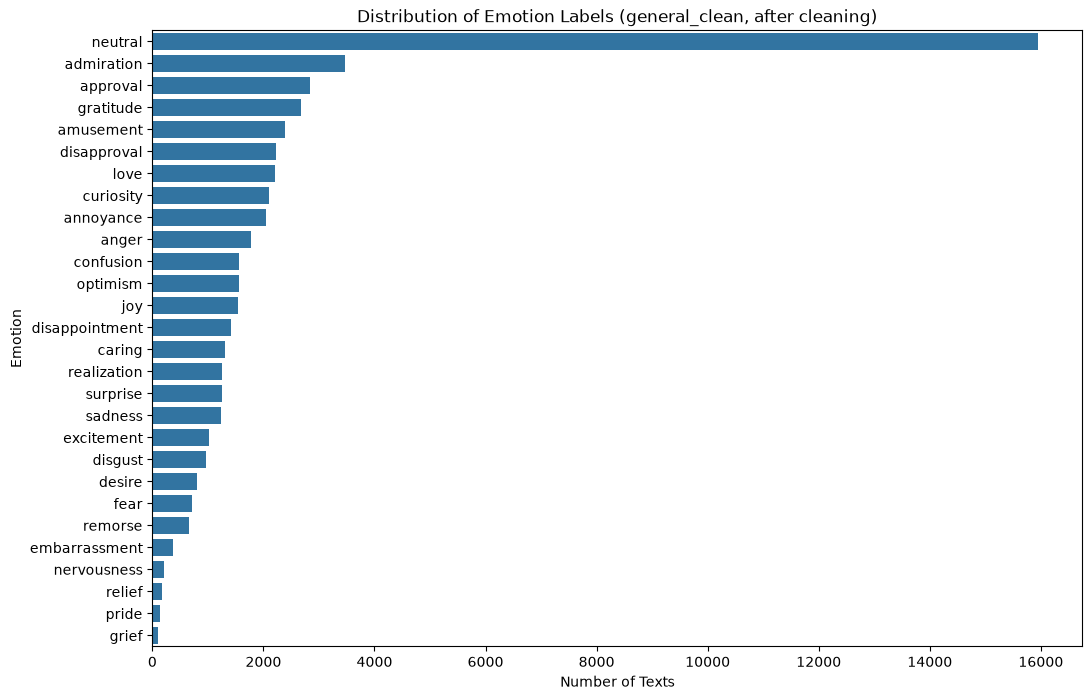

In [45]:
plt.figure(figsize=(12, 8))

sns.barplot(
    data=clean_label_summary,
    x='Count',
    y='Emotion'
)

plt.title('Distribution of Emotion Labels (general_clean, after cleaning)')
plt.xlabel('Number of Texts')
plt.ylabel('Emotion')

plt.show()


In [46]:
print("Most Common Emotion (cleaned):", clean_label_summary.iloc[0].to_dict())
print("Least Common Emotion (cleaned):", clean_label_summary.iloc[-1].to_dict())

clean_imbalance_ratio = clean_label_summary['Count'].max() / clean_label_summary['Count'].min()
print("Imbalance ratio (cleaned):", round(clean_imbalance_ratio, 2))


Most Common Emotion (cleaned): {'Emotion': 'neutral', 'Count': 15950, 'Percentage': 29.54}
Least Common Emotion (cleaned): {'Emotion': 'grief', 'Count': 97, 'Percentage': 0.18}
Imbalance ratio (cleaned): 164.43


### Text length & word count (on `general_clean`)


In [47]:
text_length = general_clean['text'].str.len()
word_count = general_clean['text'].str.split().str.len()

text_statistics = pd.DataFrame({
    'Metric': ['Mean', 'Median', 'Minimum', 'Maximum', 'Standard Deviation'],
    'Character Length': [
        text_length.mean(), text_length.median(), text_length.min(),
        text_length.max(), text_length.std()
    ],
    'Word Count': [
        word_count.mean(), word_count.median(), word_count.min(),
        word_count.max(), word_count.std()
    ]
})

text_statistics.round(2)


,Metric,Character Length,Word Count
0,Mean,68.60,12.87
1,Median,65.00,12.00
2,Minimum,2.00,1.00
3,Maximum,703.00,33.00
4,Standard Deviation,36.59,6.68


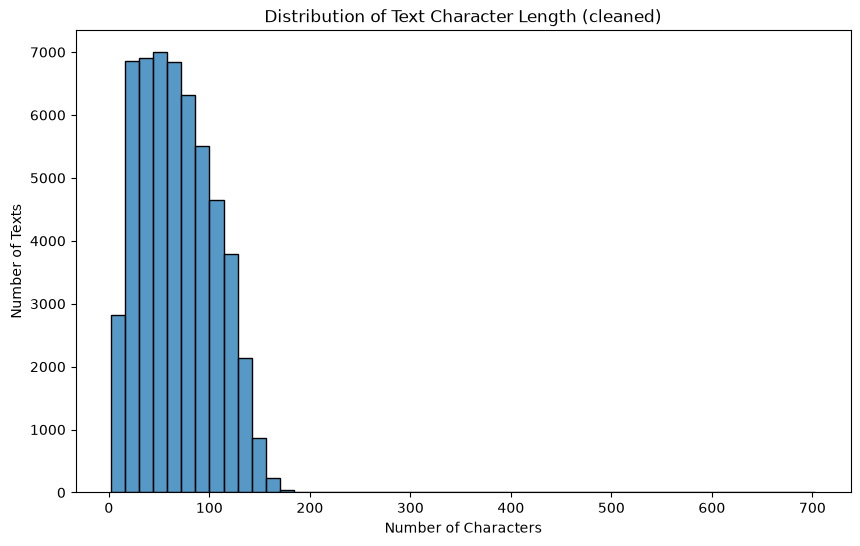

In [48]:
plt.figure(figsize=(10, 6))

sns.histplot(text_length, bins=50)

plt.title('Distribution of Text Character Length (cleaned)')
plt.xlabel('Number of Characters')
plt.ylabel('Number of Texts')

plt.show()


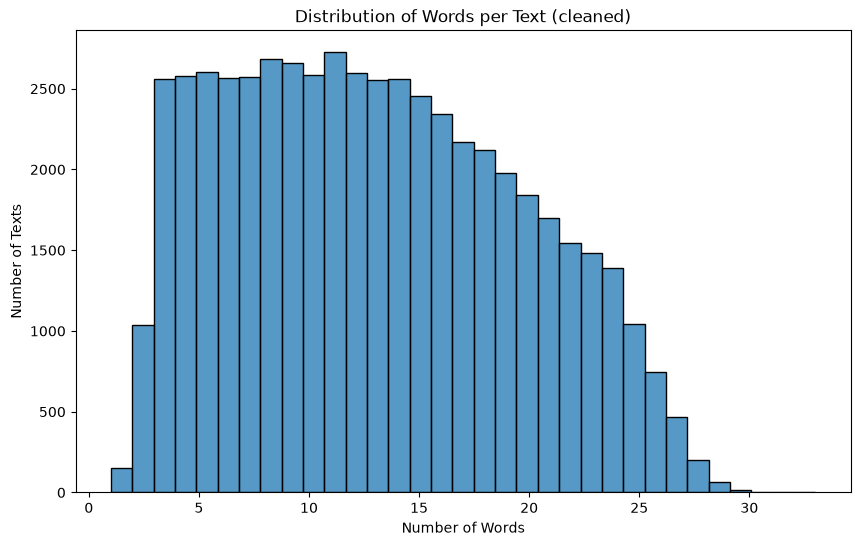

In [49]:
plt.figure(figsize=(10, 6))

sns.histplot(word_count, bins=33)

plt.title('Distribution of Words per Text (cleaned)')
plt.xlabel('Number of Words')
plt.ylabel('Number of Texts')

plt.show()


In [50]:
shortest_texts = general_clean.loc[text_length.nsmallest(10).index, ['text', 'label']]
shortest_texts


,text,label
45744,XD,neutral
52359,ok,neutral
400,(:),neutral
1015,:((,neutral
1028,:^(,neutral
28149,No.,neutral
46751,Yes,neutral
50670,art,neutral
371,#YES,neutral
8920,Fuck,disgust


In [51]:
longest_texts = general_clean.loc[text_length.nlargest(10).index, ['text', 'label']]
longest_texts


,text,label
40925,This person is the smartest person to play tow...,admiration
8800,For your kindness to mobile users I give a pla...,neutral
51277,here you go: |Games|Home|Away|Team|vs W-L 18-1...,neutral
27914,No the whippet sound is WUBWUBWUBWUBWUBWUBWUBW...,neutral
5937,Communism naturally results in dictatorship. W...,neutral
50543,"ackchyually, it's *r/woooosh ^^^^^I'm ^^^^^a ^...",neutral
1863,A supposedly professional article banging on a...,disapproval
9079,Funny they decided to show a bunch of T2 image...,amusement
42186,Venezuela should be one of the wealthiest and ...,approval
40233,This is awesome. Always been wanting more hist...,admiration


## Step 7 — Findings & Conclusion

### Raw dataset

The raw GoEmotions dataset consists of 211,225 annotation records (37 columns: text info, metadata, and 28 emotion-label columns), with no missing values or fully duplicated rows. Because each text can be rated by several annotators, the same text appears multiple times (58,011 unique IDs / 57,732 unique texts vs. 211,225 rows), and 1.61% of rows (3,411) are `example_very_unclear` with no emotion label. Emotion labels are heavily imbalanced (`neutral` 26.18% vs `grief` 0.32%, ~82:1), and 17.04% of rows carry more than one emotion label.

### Cleaning 


Applying cleaning code removes the 3,411 unclear rows, then aggregates the remaining 207,814 annotator-level rows by text, keeping only emotions with at least 2 votes and resolving each text to its single rarest qualifying emotion. This collapses the data to **53,994 unique texts, each with exactly one label**, with zero duplicate texts remaining.

### Cleaned dataset

`neutral` remains the most common label (15,950 texts, ~29.5%) and `grief` the least common (97 texts, ~0.18%) — the class imbalance persists (and is slightly more extreme) after cleaning, so it should still be accounted for during model training/evaluation (e.g. avoid plain accuracy, consider class weighting or stratified sampling). Text length statistics are broadly consistent with the raw exploration: short, tweet/comment-length texts, which remain well suited to Transformer-based classification with a modest max sequence length.

### Implications for the group project

- The **modeling dataset going forward should be `general_clean`** (`text`, `label`), not the raw multi-hot `general_df` — it already has unclear examples removed and one resolved label per text.
- The raw multi-label/co-occurrence analysis (Step 4) is only meaningful on the pre-cleaning data and is kept here purely as documentation of *why* the rarest-label cleaning strategy was needed.
- Any further preprocessing (tokenization, train/val/test split, class balancing) should be built on top of `general_clean`.
